In [55]:
# This notebook creates spatial distribution maps of energy poverty
import numpy as np
import pandas as pd

df = pd.read_parquet("INDIA/DATA/4.IN_MASTER_DATASET.parquet", engine="pyarrow")


In [56]:
#sorted(df["hv024RegionDivision"].dropna().unique())

In [57]:
region_lookup = {
1: "Jammu & Kashmir",
2: "Himachal Pradesh",
3: "Punjab",
4: "Chandigarh",
5: "Uttarakhand",
6: "Haryana",
7: "NCT of Delhi",
8: "Rajasthan",
9: "Uttar Pradesh",
10: "Bihar",
11: "Sikkim",
12: "Arunachal Pradesh",
13: "Nagaland",
14: "Manipur",
15: "Mizoram",
16: "Tripura",
17: "Meghalaya",
18: "Assam",
19: "West Bengal",
20: "Jharkhand",
21: "Odisha",
22: "Chhattisgarh",
23: "Madhya Pradesh",
24: "Gujarat",
25: "Dadra & Nagar Haveli and Daman & Diu",
27: "Maharashtra",
28: "Andhra Pradesh",
29: "Karnataka",
30: "Goa",
31: "Lakshadweep",
32: "Kerala",
33: "Tamil Nadu",
34: "Puducherry",
35: "Andaman & Nicobar Islands",
36: "Telangana",
37: "Ladakh"
}

df["region_name"] = df["hv024RegionDivision"].map(region_lookup)

df[["hv024RegionDivision","region_name"]].head(5)

,hv024RegionDivision,region_name
0,36,Telangana
1,36,Telangana
2,36,Telangana
3,36,Telangana
4,36,Telangana


In [ ]:
region_headcount = (
    df.groupby("region_name")
      .apply(lambda x: (x["EnergyPoor"] * x["weight"]).sum() / x["weight"].sum() * 100)
      .reset_index(name="headcount_pct")
)

region_headcount["headcount_pct"] = region_headcount["headcount_pct"].round(0)

region_headcount

In [59]:
import geopandas as gpd

in_map = gpd.read_file(
    r"INDIA/SHPS/sdr_subnational_boundaries.shp"
)

in_map.head(5)

,ISO,FIPS,DHSCC,SVYTYPE,SVYYEAR,CNTRYNAMEE,CNTRYNAMEF,CNTRYNAMES,DHSREGEN,DHSREGFR,...,REGNAME,OTHREGVAR,OTHREGCO,OTHREGNA,LEVELCO,LEVELNA,REPALLIND,REGNOTES,SVYNOTES,geometry
0,IN,IN,IA,DHS,2020.0,India,None,None,Andaman & Nicobar Islands,None,...,Andaman & Nicobar Islands,NULL,9999.0,NULL,Admin1,States,yes,"These boundaries do not align with SSIB, but d...",None,"MULTIPOLYGON (((93.80542 6.85081, 93.8 6.85042..."
1,IN,IN,IA,DHS,2020.0,India,None,None,Andhra Pradesh,None,...,Andhra Pradesh,NULL,9999.0,NULL,Admin1,States,yes,None,None,"MULTIPOLYGON (((80.13416 14.06539, 80.13245 14..."
2,IN,IN,IA,DHS,2020.0,India,None,None,Arunachal Pradesh,None,...,Arunachal Pradesh,NULL,9999.0,NULL,Admin1,States,yes,None,None,"POLYGON ((96.06947 29.37235, 96.0973 29.36356,..."
3,IN,IN,IA,DHS,2020.0,India,None,None,Assam,None,...,Assam,NULL,9999.0,NULL,Admin1,States,yes,None,None,"POLYGON ((95.95689 27.96913, 95.97746 27.9685,..."
4,IN,IN,IA,DHS,2020.0,India,None,None,Bihar,None,...,Bihar,NULL,9999.0,NULL,Admin1,States,yes,None,None,"POLYGON ((84.14555 27.51833, 84.14722 27.51139..."


In [60]:
in_map.columns

Index(['ISO', 'FIPS', 'DHSCC', 'SVYTYPE', 'SVYYEAR', 'CNTRYNAMEE',
       'CNTRYNAMEF', 'CNTRYNAMES', 'DHSREGEN', 'DHSREGFR', 'DHSREGSP', 'SVYID',
       'REG_ID', 'Svy_Map', 'MULTLEVEL', 'LEVELRNK', 'REGVAR', 'REGCODE',
       'REGNAME', 'OTHREGVAR', 'OTHREGCO', 'OTHREGNA', 'LEVELCO', 'LEVELNA',
       'REPALLIND', 'REGNOTES', 'SVYNOTES', 'geometry'],
      dtype='object')

In [61]:
#sorted(in_map["REGNAME"].dropna().unique())

In [62]:
region_headcount.loc[
    region_headcount["region_name"] == "Dadra & Nagar Haveli and Daman & Diu",
    "region_name"
] = "Dadra & Nagar Haveli & Daman & Diu"

In [63]:
in_gdf = in_map.merge(
    region_headcount,
    left_on="REGNAME",
    right_on="region_name",
    how="left"
)
in_gdf[["REGNAME", "headcount_pct"]]


,REGNAME,headcount_pct
0,Andaman & Nicobar Islands,13.0
1,Andhra Pradesh,21.0
2,Arunachal Pradesh,48.0
3,Assam,60.0
4,Bihar,70.0
5,Chandigarh,6.0
6,Chhattisgarh,64.0
7,Dadra & Nagar Haveli & Daman & Diu,29.0
8,Goa,3.0
9,Gujarat,33.0


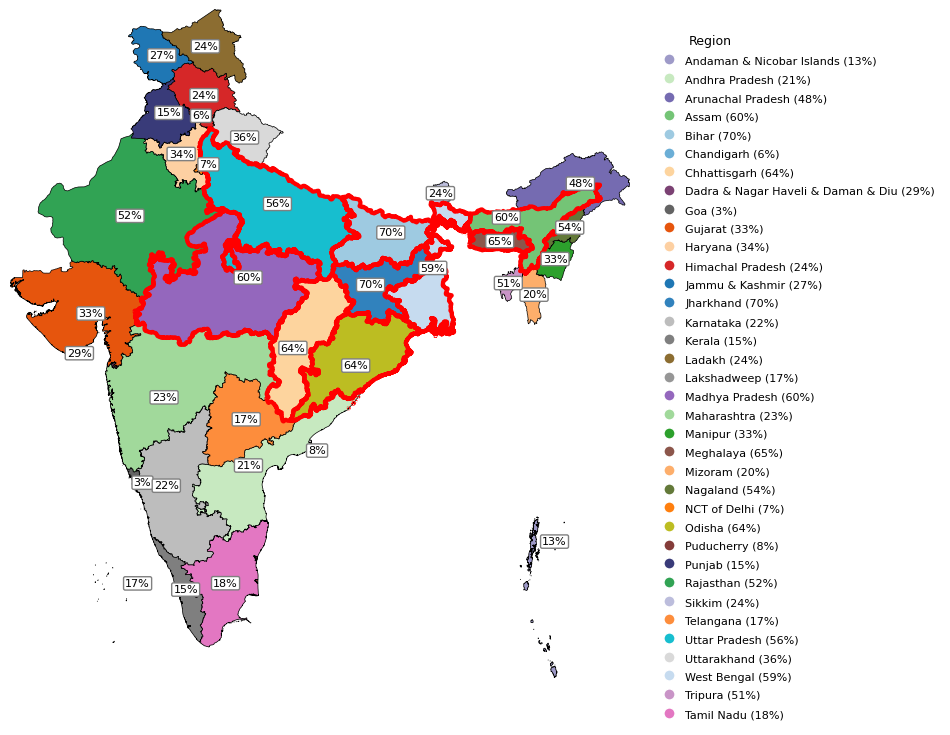

In [64]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(8, 9))

# distinct custom colors
custom_colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b",
    "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#393b79", "#637939",
    "#8c6d31", "#843c39", "#7b4173", "#3182bd", "#31a354", "#756bb1",
    "#636363", "#e6550d", "#969696", "#6baed6", "#74c476", "#fd8d3c",
    "#9e9ac8", "#bdbdbd", "#c7e9c0", "#fdd0a2", "#c6dbef", "#fdae6b",
    "#a1d99b", "#9ecae1", "#fdd49e", "#bcbddc", "#c994c7", "#d9d9d9"
]

regions = in_gdf["REGNAME"].unique().tolist()

# optional shuffle to separate nearby colors a bit more
np.random.shuffle(custom_colors)

# region -> color map
color_map = dict(zip(regions, custom_colors[:len(regions)]))
in_gdf["color"] = in_gdf["REGNAME"].map(color_map)

# region -> headcount lookup
headcount_lookup = dict(zip(in_gdf["REGNAME"], in_gdf["headcount_pct"]))

# plot map
in_gdf.plot(
    color=in_gdf["color"],
    linewidth=0.5,
    edgecolor="black",
    ax=ax
)

q75 = in_gdf["headcount_pct"].quantile(0.75)
top_quartile = in_gdf[in_gdf["headcount_pct"] >= q75]

top_quartile.boundary.plot(
    ax=ax,
    edgecolor="red",
    linewidth=3
)

# manual label adjustments for small regions
label_offsets_in = {
    "NCT of Delhi": (0.4, 0.2),
    "Chandigarh": (0.4, 0.2),
    "Puducherry": (0.4, -0.2),
    "Lakshadweep": (0.5, 0.0),
    "Andaman & Nicobar Islands": (1.0, 0.0),
    "Dadra & Nagar Haveli & Daman & Diu": (0.5, 0.0),
    "Goa": (0.3, -0.2),
       "Assam": (0.8, 0.5)
}

# add % labels inside regions
for idx, row in in_gdf.iterrows():
    point = row.geometry.representative_point()
    x, y = point.x, point.y

    if row["REGNAME"] in label_offsets_in:
        dx, dy = label_offsets_in[row["REGNAME"]]
        x += dx
        y += dy

    ax.text(
        x,
        y,
        f"{int(row['headcount_pct'])}%",
        ha="center",
        va="center",
        fontsize=8,
        bbox=dict(facecolor="white", edgecolor="gray", boxstyle="round,pad=0.15")
    )

ax.axis("off")

# create legend with region + percentage
legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=f"{region} ({int(headcount_lookup[region])}%)",
        markerfacecolor=color_map[region],
        markersize=8
    )
    for region in regions
]

legend = ax.legend(
    handles=legend_elements,
    title="Region",
    bbox_to_anchor=(1.02, 0.45),
    loc="center left"
    ,handletextpad=0.2  
)

# Myanmar-style title alignment:
# not fully left, not fully centered, slightly left
legend._legend_box.align = "center"
legend.get_title().set_ha("center")
legend.get_title().set_position((-85, 0))

# font sizes
for text in legend.get_texts():
    text.set_fontsize(8)
legend.get_title().set_fontsize(9)

# remove legend frame
legend.get_frame().set_linewidth(0)
legend.get_frame().set_edgecolor("none")

# tighten map bounds
xmin, ymin, xmax, ymax = in_gdf.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.margins(0)

# save figure
plt.savefig(
    r"INDIA/MAP/Figure3_india_energy_poverty_headcount.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()